# Basic System

This notebook provides code for implementing a very simple machine learning system for named entity recognition.
It uses logistic regression and one feature (the token itself).
Links to information about the packages are provided. Your job is to document the code and use it to train a system. You can then use your evaluation code to provide the first basic evaluation of your system.

*Note:* In the next assignment, you can use this as a basis to experiment with more features and more machine learning methods.

### About this Notebook:
- The notebook is structured similarly to the assignment pdf. Each question contains suggestions to help guide you, but remember to follow the requirements in the PDF for your final answers.

In [11]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer

import sys

# If you want to include other modules, you can add them here
# Please note the recommendations on using modules in the Programming General Guidelines

#recommended resource for examples: https://scikit-learn.org/stable/modules/feature_extraction.html

from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2.1. Load and inspect the data
**Suggestions:**
 - Download the following files form from canvas ,and place them in the folder "`./data/conll2003`":
   - `conll2003.train.conll`, `conll2003.test.conll`, `conll2003.dev.conll`


In [2]:
def extract_features(inputfile):
    """
    Extract features from the input file.
    Arguments:
        inputfile: Path to the input data file.
    Returns:
        data: List of feature dictionaries for each token.
    """
    data = []
    with open(inputfile, 'r', encoding='utf8') as infile:
        for line in infile:
            components = line.rstrip('\n').split()
            if len(components) > 0:
                token = components[0]
                feature_dict = {'token':token, 'POS':components[1], 'case': 'uppercase' if token[0].isupper() else 'lowercase'}
                data.append(feature_dict)
    return data

In [1]:
def extract_features_and_labels(trainingfile):
    """Extract features and labels from the training file.
    Arguments:
        trainingfile: Path to the training data file.
    Returns:
        data: List of feature dictionaries for each token.
        targets: List of target labels for each token.
    """
    data = []
    targets = []
    with open(trainingfile, 'r', encoding='utf8') as infile:
        for line in infile:
            components = line.rstrip('\n').split()
            if len(components) > 0:
                token = components[0]
                feature_dict = {'token':token, 'POS':components[1], 'case': 'uppercase' if token[0].isupper() else 'lowercase'}
                data.append(feature_dict)
                # gold NER-label is in the last column
                targets.append(components[-1])
    return data, targets

In [7]:
data_folder = "../../data/conll2003/"

train_file = data_folder + "conll2003.train.conll"
test_file = data_folder + "conll2003.test.conll"
dev_file = data_folder + "conll2003.dev.conll"

In [14]:
data, targets = extract_features_and_labels(train_file)
print(f"Number of training instances: {len(data)}")
for i in range(3):
    print(f"example training instance {i+1}: {data[i]}, label: {targets[i]}")

Number of training instances: 203621
example training instance 1: {'token': 'EU'}, label: B-ORG
example training instance 2: {'token': 'rejects'}, label: O
example training instance 3: {'token': 'German'}, label: B-MISC


In [13]:
print(set(targets))

{'B-LOC', 'I-ORG', 'I-MISC', 'B-MISC', 'O', 'B-ORG', 'I-PER', 'I-LOC', 'B-PER'}


## 2.2. Data analysis: feature and label distributions
**Suggestions:**

- Inspect which unique NER labels there are and plot their distribution (tip: look into the `Counter()`)
- Evaluate the samples per class to answer the questions in the pdf

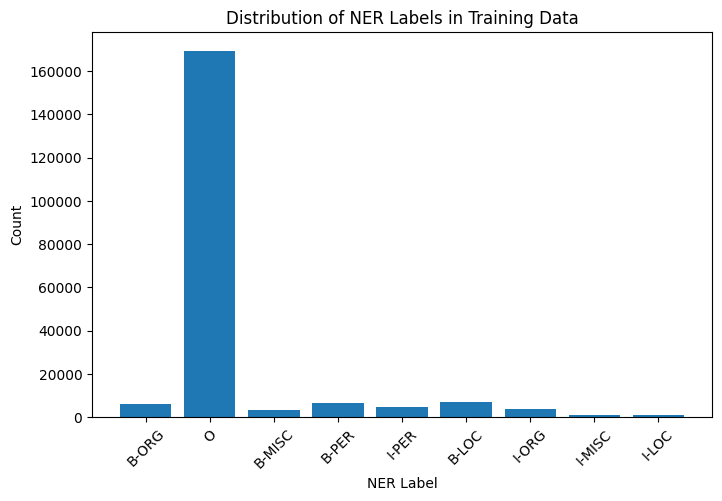

Label: B-ORG, Count: 6321
Label: O, Count: 169578
Label: B-MISC, Count: 3438
Label: B-PER, Count: 6600
Label: I-PER, Count: 4528
Label: B-LOC, Count: 7140
Label: I-ORG, Count: 3704
Label: I-MISC, Count: 1155
Label: I-LOC, Count: 1157


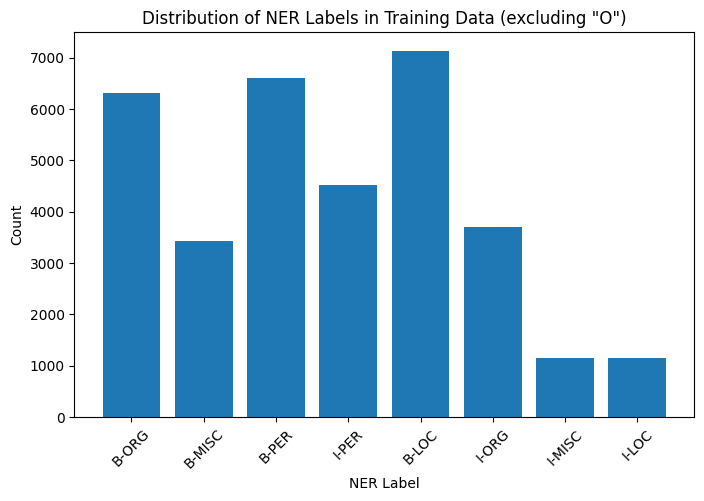

203621


In [19]:
# NER label distribution in train set
Counter(targets)
plt.figure(figsize=(8, 5))
target_counts = Counter(targets)
plt.bar(target_counts.keys(), target_counts.values())
plt.xlabel('NER Label')
plt.ylabel('Count')
plt.title('Distribution of NER Labels in Training Data')
plt.xticks(rotation=45)
plt.show()

for key, value in target_counts.items():
    print(f"Label: {key}, Count: {value}")

# Remove the 'O' category from target_counts
filtered_counts = Counter({k: v for k, v in target_counts.items() if k != 'O'})
plt.figure(figsize=(8, 5))
plt.bar(filtered_counts.keys(), filtered_counts.values())
plt.xlabel('NER Label')
plt.ylabel('Count')
plt.title('Distribution of NER Labels in Training Data (excluding "O")')
plt.xticks(rotation=45)
plt.show()

print(len(targets))

{'token': 'EU', 'POS': 'NNP'}
[('NNP', 34392), ('NN', 23899), ('CD', 19704), ('IN', 19064), ('DT', 13453), ('JJ', 11831), ('NNS', 9903), ('VBD', 8293), ('.', 7389), (',', 7291)]


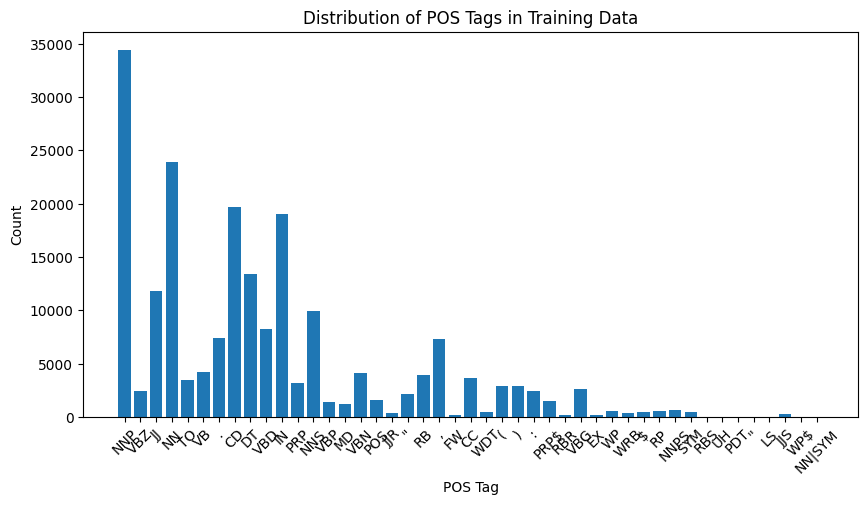

In [29]:
# POS distribution
data, targets = extract_features_and_labels(train_file)
print(data[0])
pos_counts = Counter([item['POS'] for item in data])
print(pos_counts.most_common(10))
plt.figure(figsize=(10, 5))
plt.bar(pos_counts.keys(), pos_counts.values())
plt.xlabel('POS Tag')
plt.ylabel('Count')
plt.title('Distribution of POS Tags in Training Data')
plt.xticks(rotation=45)
plt.show()

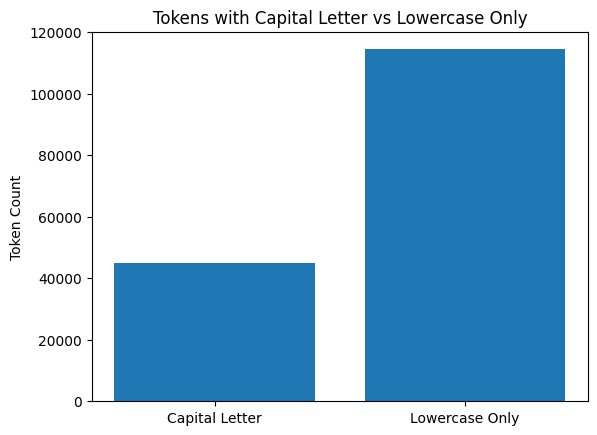

In [30]:
# Capital vs Lowercase tokens
capital_count = sum(1 for item in data if any(c.isupper() for c in item['token']))
lowercase_count = sum(1 for item in data if item['token'].islower())

plt.bar(['Capital Letter', 'Lowercase Only'], [capital_count, lowercase_count])
plt.ylabel('Token Count')
plt.title('Tokens with Capital Letter vs Lowercase Only')
plt.show()



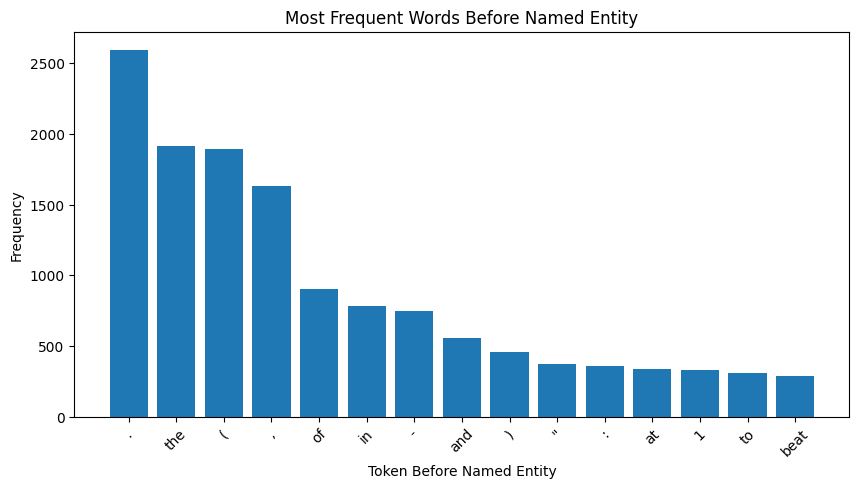

[('.', 2594), ('the', 1915), ('(', 1895), (',', 1634), ('of', 903), ('in', 780), ('-', 744), ('and', 553), (')', 454), ('"', 372), (':', 356), ('at', 334), ('1', 330), ('to', 307), ('beat', 290)]


In [33]:
# Find most frequent words before a named entity (not 'O')
prev_tokens = []
for idx in range(1, len(targets)):
    if targets[idx] != 'O':
        prev_tokens.append(data[idx-1]['token'].lower())

prev_counter = Counter(prev_tokens)
most_common_prev = prev_counter.most_common(15)

tokens, counts = zip(*most_common_prev)
plt.figure(figsize=(10, 5))
plt.bar(tokens, counts)
plt.xlabel('Token Before Named Entity')
plt.ylabel('Frequency')
plt.title('Most Frequent Words Before Named Entity')
plt.xticks(rotation=45)
plt.show()
print(most_common_prev)

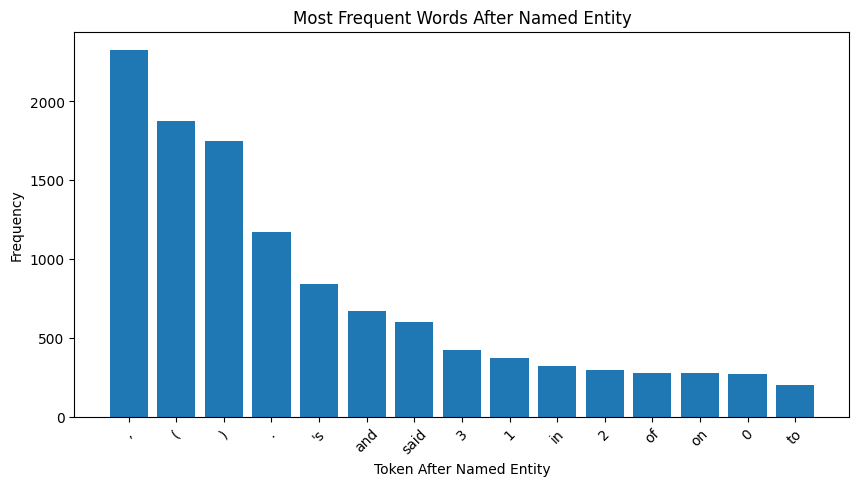

[(',', 2326), ('(', 1876), (')', 1750), ('.', 1169), ("'s", 842), ('and', 670), ('said', 601), ('3', 425), ('1', 372), ('in', 322), ('2', 296), ('of', 280), ('on', 276), ('0', 268), ('to', 202)]


In [35]:
# Find most frequent words after a named entity (not 'O')
next_tokens = []
for idx in range(len(targets) - 1):
    if targets[idx] != 'O':
        next_tokens.append(data[idx + 1]['token'].lower())

next_counter = Counter(next_tokens)
most_common_next = next_counter.most_common(15)

tokens, counts = zip(*most_common_next)
plt.figure(figsize=(10, 5))
plt.bar(tokens, counts)
plt.xlabel('Token After Named Entity')
plt.ylabel('Frequency')
plt.title('Most Frequent Words After Named Entity')
plt.xticks(rotation=45)
plt.show()
print(most_common_next)

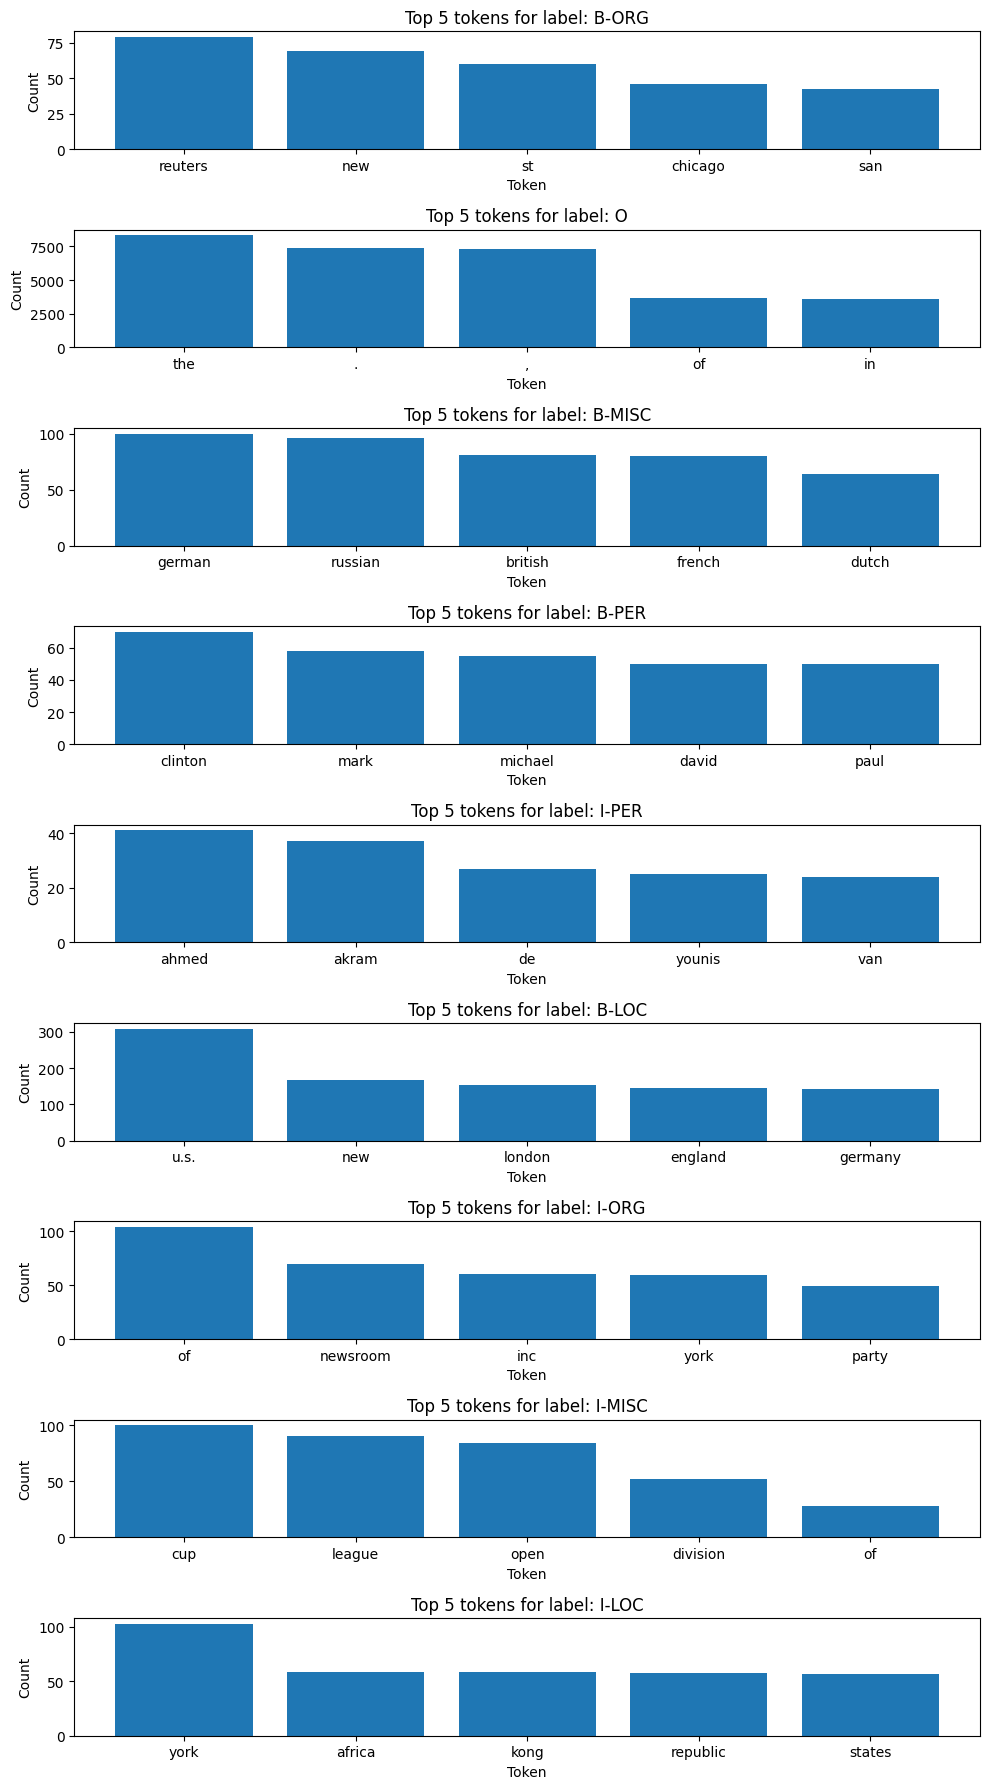

In [36]:
label_token_counter = {}
for label in target_counts.keys():
    tokens_for_label = [data[i]['token'].lower() for i in range(len(targets)) if targets[i] == label]
    label_token_counter[label] = Counter(tokens_for_label).most_common(5)

fig, axes = plt.subplots(nrows=len(label_token_counter), figsize=(10, 2 * len(label_token_counter)))
if len(label_token_counter) == 1:
    axes = [axes]
for ax, (label, top_tokens) in zip(axes, label_token_counter.items()):
    tokens, counts = zip(*top_tokens)
    ax.bar(tokens, counts)
    ax.set_title(f"Top 5 tokens for label: {label}")
    ax.set_ylabel("Count")
    ax.set_xlabel("Token")
plt.tight_layout()
plt.show()


In [ ]:

for label in target_counts.keys():
    tokens_for_label = [data[i]['token'].lower() for i in range(len(targets)) if targets[i] == label]
    label_token_counter[label] = Counter(tokens_for_label).most_common(5)

fig, axes = plt.subplots(nrows=len(label_token_counter), figsize=(10, 2 * len(label_token_counter)))
if len(label_token_counter) == 1:
    axes = [axes]
for ax, (label, top_tokens) in zip(axes, label_token_counter.items()):
    tokens, counts = zip(*top_tokens)
    ax.bar(tokens, counts)
    ax.set_title(f"Top 5 tokens for label: {label}")
    ax.set_ylabel("Count")
    ax.set_xlabel("Token")
plt.tight_layout()
plt.show()

## 2.3. Evaluation

**Suggestions:**
- Create a sample file with the ground_truth features and labels `sample_gt.conll` and a sample prediction file with the predictions `sample_pred.conll`.
- Create a function functions to calculate different metrics from two files: e.g. precision(), recall(), f-score(), confusion_matrix(). (Note you can use packages, e.g. `sklearn`)

In [38]:
with open("sample_gt.conll", "w") as outfile:
    for i in range(50):
        token = data[i]['token']
        label = targets[i]
        outfile.write(f"{token} {label}\n")

In [ ]:
import random
with open("sample_pred.conll", "w") as outfile:
    for i in range(50):
        token = data[i]['token']
        # For demonstration, I used random options
        predicted_label = random.choice(list(target_counts.keys()))
        outfile.write(f"{token} {predicted_label}\n")

              precision    recall  f1-score   support

       B-LOC      0.143     0.500     0.222         2
      B-MISC      0.000     0.000     0.000         4
       B-ORG      0.000     0.000     0.000         3
       B-PER      0.143     1.000     0.250         1
       I-LOC      0.000     0.000     0.000         0
      I-MISC      0.000     0.000     0.000         0
       I-ORG      0.000     0.000     0.000         2
       I-PER      0.000     0.000     0.000         1
           O      0.600     0.081     0.143        37

    accuracy                          0.100        50
   macro avg      0.098     0.176     0.068        50
weighted avg      0.453     0.100     0.120        50



/home/vera/MA/ML4NLP/ma-ml4nlp-labs-1/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vera/MA/ML4NLP/ma-ml4nlp-labs-1/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vera/MA/ML4NLP/ma-ml4nlp-labs-1/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

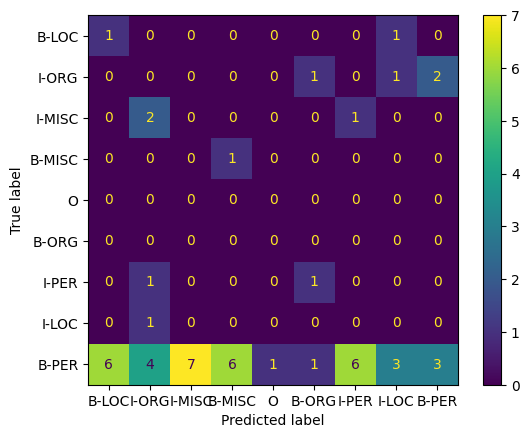

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

   
with open("sample_gt.conll", "r") as gt_file:
    gt_lines = gt_file.readlines()
    gt_targets = [line.split()[-1] for line in gt_lines if line.strip()]
with open("sample_pred.conll", "r") as pred_file:
    pred_lines = pred_file.readlines()
    pred_targets = [line.split()[-1] for line in pred_lines if line.strip()]


report = classification_report(gt_targets[:50], pred_targets[:50], digits=3)

print(report)

cm = confusion_matrix(gt_targets[:50], pred_targets[:50])
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=set(targets))
disp.plot()

In [27]:
def evaluate_ner(gold_labels, pred_labels): # created a nice function for evaluation on token level
    report = classification_report(gold_labels, pred_labels, digits=3)
    print(report)
    print("Normalized:")
    cm = confusion_matrix(gold_labels, pred_labels, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=set(gold_labels))
    disp.plot(values_format = '.2f')
    print("Not normalized:")
    cm = confusion_matrix(gold_labels, pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=set(gold_labels))
    disp.plot(values_format = 'd')

## 2.4. Train and evaluate basic NERC system
**Suggestions:**
- Train the Logistic regression classifier on your dataset and evaluate the performance on your various metrics.
- Transfer your code to a python file 

In [3]:
def create_classifier(train_features, train_targets):
    """
    Create and train a logistic regression classifier.
    Arguments:
        train_features: List of feature dictionaries for training instances.
        train_targets: List of target labels for training instances.
    Returns:
        model: Trained Logistic Regression model.
        vec: Fitted DictVectorizer.
    """
    logreg = LogisticRegression()
    vec = DictVectorizer()
    features_vectorized = vec.fit_transform(train_features)
    model = logreg.fit(features_vectorized, train_targets)
    
    return model, vec

In [4]:
def classify_data(model, vec, inputdata, outputfile):
    """
    Classify input data and write predictions to output file.
    Arguments:
        model: Trained classification model.
        vec: Fitted DictVectorizer.
        inputdata: Path to input data file.
        outputfile: Path to output file where predictions will be written.
    Returns:
        None (the results are written to the outputfile)
    """
    features = extract_features(inputdata)
    features = vec.transform(features)
    predictions = model.predict(features)
    outfile = open(outputfile, 'w')
    counter = 0
    for line in open(inputdata, 'r'):
        if len(line.rstrip('\n').split()) > 0:
            outfile.write(line.rstrip('\n') + '\t' + predictions[counter] + '\n')
            counter += 1
    outfile.close()

In [30]:
train_features, train_targets = extract_features_and_labels(train_file)
model, vec = create_classifier(train_features, train_targets)
classify_data(model, vec, dev_file, "pred.txt")
print("Pred written to pred.txt")


/home/vera/MA/ML4NLP/ma-ml4nlp-labs-1/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pred written to pred.txt


              precision    recall  f1-score   support

       B-LOC      0.870     0.746     0.803      1837
      B-MISC      0.782     0.713     0.746       922
       B-ORG      0.772     0.650     0.706      1341
       B-PER      0.480     0.839     0.611      1842
       I-LOC      0.758     0.525     0.621       257
      I-MISC      0.836     0.457     0.591       346
       I-ORG      0.640     0.465     0.539       751
       I-PER      0.724     0.405     0.519      1307
           O      0.989     0.993     0.991     42759

    accuracy                          0.936     51362
   macro avg      0.761     0.644     0.681     51362
weighted avg      0.943     0.936     0.936     51362

Normalized:
Not normalized:


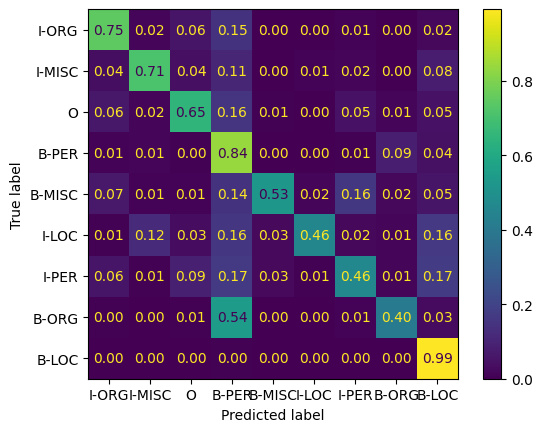

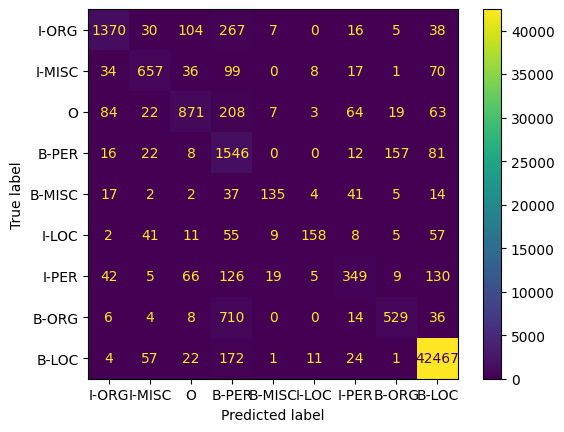

In [31]:
with open("pred.txt", "r") as pred_file:
    pred_lines = pred_file.readlines()
    pred_targets = [line.split()[-1] for line in pred_lines if line.strip()]
    gt_targets = [line.split()[-2] for line in pred_lines if line.strip()]
evaluate_ner(gt_targets, pred_targets)

### (**optional**) 2.4.2 Convert to a python file:
- This is part is optional for now but will be required for assignment 2, so it is good practice.

Description:
- To convert the code to a python file, you should place all the relevant functions in one `.py` file.
- Add the following lines to the bottom, which ensure that if you call the function from a terminal, the lines within it will be exectued:


In [ ]:
def main(argv=None):
    """TODO fill in docstring"""

    #a very basic way for picking up commandline arguments
    if argv is None:
        argv = sys.argv
        
    #Note 1: argv[0] is the name of the python program if you run your program as: python program1.py arg1 arg2 arg3
    #Note 2: sys.argv is simple, but gets messy if you need it for anything else than basic scenarios with few arguments
    #you'll want to move to something better. e.g. argparse (easy to find online)
    
    
    #you can replace the values for these with paths to the appropriate files for now, e.g. by specifying values in argv
    #argv = ['mypython_program','','','']
    trainingfile = argv[1]
    inputfile = argv[2]
    outputfile = argv[3]
    
    training_features, gold_labels = extract_features_and_labels(trainingfile)
    ml_model, vec = create_classifier(training_features, gold_labels)
    classify_data(ml_model, vec, inputfile, outputfile)

# uncomment this when using this in a script    
if __name__ == '__main__':
    # Code below is executed when this python file is called from terminal
    main()


In [ ]:
# remember that the first element of the list is not used 
# (since this is the `python command when the args are read from sys.argv)
# make sure to complete the rest of the list assigned to args correctly
args = ['python']
main(args)